# N14 — Safety Car Probability Model

This notebook trains a Safety Car probability classifier on the labeled dataset
produced by N13. The model compares three prediction windows (3, 5, 7 laps) and
selects the best one by lift over baseline — the core signal consumed by the
Strategy Agent to anticipate full-course caution periods.

**Architecture:** `LightGBM binary classifier → Platt calibration → P(SC | lap state)`

**Validation:** temporal split — train 2023+2024 / test 2025.

**Input:** `data/processed/sc_labeled/sc_labeled_2023_2025.parquet`

**Exports:**
- `data/models/safety_car_probability/lgbm_sc_v1.pkl`
- `data/models/safety_car_probability/calibrator_sc_v1.pkl`
- `data/models/safety_car_probability/feature_list_v1.json`

---

## Step 0 — Setup and Imports


In [15]:
# ── Step 0 — Setup ────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")
import pathlib
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
from scipy.special import expit
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    precision_recall_curve, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import shap

In [16]:
# ── Repo root ─────────────────────────────────────────────────────────────────
repo_root = pathlib.Path.cwd()
while not (repo_root / ".git").exists():
    repo_root = repo_root.parent
# ── Paths ─────────────────────────────────────────────────────────────────────
OUTPUTS    = repo_root / "notebooks" / "strategy" / "sc_probability" / "outputs"
PROCESSED  = repo_root / "data" / "processed" / "sc_labeled"
EXPORT_DIR = repo_root / "data" / "models" / "safety_car_probability"

OUTPUTS.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root  : {repo_root}")
print(f"Outputs    : {OUTPUTS}")
print(f"Processed  : {PROCESSED}")
print(f"Export dir : {EXPORT_DIR}")

Repo root  : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager
Outputs    : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\sc_probability\outputs
Processed  : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\processed\sc_labeled
Export dir : c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\safety_car_probability


---

## Step 1 — Load and inspect the dataset

We load the parquet generated in N13 and run a first inspection: shape, columns,
target variable distribution, and null counts. The goal is to confirm the dataset
is clean and understand the class imbalance before designing the training pipeline.


In [17]:
# ── Step 1 — Load & Inspect Dataset ───────────────────────────────────────────
df = pd.read_parquet(PROCESSED / "sc_labeled_2023_2025.parquet")

print(f"Shape    : {df.shape}")
print(f"Columns  : {list(df.columns)}")
print(f"\nDtypes   :\n{df.dtypes}")
df.head(3)


Shape    : (3275, 43)
Columns  : ['LapNumber', 'lap_time_mean', 'lap_time_std', 'lap_time_min', 'lap_time_cv', 'lap_time_trend_5', 'n_drivers', 'n_drivers_delta', 'tyre_life_mean', 'tyre_life_max', 'track_status', 'status_change_direction', 'driver_anomaly_soft_count', 'driver_anomaly_hard_count', 'max_speed_drop_pct', 'tyre_age_high_risk_count', 'active_pitstop_count', 'outlap_drivers', 'track_temp', 'air_temp', 'humidity', 'track_temp_delta', 'weather_available', 'lap_pct', 'is_lap1', 'track_status_enc', 'year', 'round', 'event_name', 'circuit_cluster', 'race_id', 'yellow_escalation_count', 'laps_since_last_yellow', 'status_changed', 'had_incident_msg', 'rcm_incident_count_prev3', 'yellow_sectors_this_lap', 'yellow_sectors_prev3', 'incident_escalation', 'sc_within_7_laps', 'sc_within_5_laps', 'sc_within_3_laps', 'circuit_sc_rate']

Dtypes   :
LapNumber                      int64
lap_time_mean                float64
lap_time_std                 float64
lap_time_min                 flo

,LapNumber,lap_time_mean,lap_time_std,lap_time_min,lap_time_cv,lap_time_trend_5,n_drivers,n_drivers_delta,tyre_life_mean,tyre_life_max,...,status_changed,had_incident_msg,rcm_incident_count_prev3,yellow_sectors_this_lap,yellow_sectors_prev3,incident_escalation,sc_within_7_laps,sc_within_5_laps,sc_within_3_laps,circuit_sc_rate
0,1,105.23705,3.299372,99.019,0.031352,1.0,20,0,2.35,4.0,...,0,1,0,2,0,0,0,0,0,0.15
1,2,100.06895,0.944459,97.974,0.009438,1.0,20,0,3.35,5.0,...,0,1,2,1,2,0,0,0,0,0.15
2,3,99.83685,0.939165,98.006,0.009407,1.0,20,0,4.35,6.0,...,1,1,3,0,3,1,0,0,0,0.15


In [18]:
print(f"Years        : {sorted(df['year'].unique())}")
print(f"\nLabel dist   :\n{df['sc_within_5_laps'].value_counts(normalize=True).round(4)}")
print(f"\nNull counts  :\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nRows per year:\n{df['year'].value_counts().sort_index()}")
print(f"\ntrack_status values: {df['track_status'].unique()}")


Years        : [2023, 2024, 2025]

Label dist   :
sc_within_5_laps
0    0.9441
1    0.0559
Name: proportion, dtype: float64

Null counts  :
lap_time_mean            4
lap_time_min             4
max_speed_drop_pct    3274
dtype: int64

Rows per year:
year
2023    1238
2024    1042
2025     995
Name: count, dtype: int64

track_status values: ['2' '1' '5']


### Results

The dataset has **3,275 laps** across 3 seasons (2023: 1,238 · 2024: 1,042 · 2025: 995), with **43 columns** covering lap timing, tyre state, track status signals, race control flags, and three SC prediction targets (3/5/7-lap windows).

Class imbalance varies by window: **sc_within_3_laps 3.5%**, **sc_within_5_laps 5.6%**, **sc_within_7_laps 7.5%**. Null counts are minimal (4 rows in lap time columns, `max_speed_drop_pct` fully null → will be dropped by zero-variance filter). `track_status` takes three values: `'1'` (green), `'2'` (yellow/SC), `'5'` (SC active) — encoded before modelling.

---

## Step 2 — Feature engineering (v3)

Preprocessing changes vs v2:
- **FEATURES list updated** to match N13 v3 output (dual anomaly soft/hard, z-scored lap times, interaction features)
- **Per-race z-score normalization** of raw lap times: removes circuit-specific scale,
  lets the model focus on within-race deviations (a 90s lap at Monaco vs a 78s lap at Monza)
- **Interaction features**: `anomaly_and_yellow` (hard anomaly AND escalating yellow simultaneously)
  and `lap1_chaos` (lap 1 combined with field size drop — captures race-start incidents)
- Weather columns: ffill within race first, global median as last resort
- Zero-variance columns dropped silently (weather NaN clusters)

**Removed from v2:** `driver_anomaly_count` (split into soft/hard), `yellow_count_prev3` (anti-predictive)

**Added in v3:** dual anomaly, lap time cv/trend, `n_drivers_delta`, `status_change_direction`,
`yellow_escalation_count`, `laps_since_last_yellow`, `incident_escalation`, `circuit_sc_rate`,
`weather_available`, z-scored lap times, interaction features

In [19]:
# ── Step 2 — Feature engineering & preprocessing (v3) ─────────────────────────

# ── Race identifier (groupby key) ─────────────────────────────────────────────
RACE_KEY = "race_id" if "race_id" in df.columns else "event_name"

# ── Drop zero-variance columns silently ──────────────────────────────────────
zero_var = [c for c in df.columns if df[c].nunique() <= 1]
if zero_var:
    print(f"Dropping zero-variance: {zero_var}")
    df = df.drop(columns=zero_var)

# ── Impute lap time nulls with per-race median ────────────────────────────────
for col in ["lap_time_mean", "lap_time_std", "lap_time_min", "lap_time_cv", "lap_time_trend_5"]:
    if col in df.columns:
        race_med = df.groupby(RACE_KEY)[col].transform("median")
        df[col] = df[col].fillna(race_med).fillna(df[col].median())

# ── Per-race z-score normalization of lap times ───────────────────────────────
for col in ["lap_time_mean", "lap_time_std", "lap_time_min"]:
    if col in df.columns:
        race_mu  = df.groupby(RACE_KEY)[col].transform("mean")
        race_sig = df.groupby(RACE_KEY)[col].transform("std").clip(lower=0.01)
        df[f"{col}_z"] = (df[col] - race_mu) / race_sig

# ── Weather: ffill within race, then global median ────────────────────────────
for col in ["track_temp", "air_temp", "humidity", "track_temp_delta"]:
    if col in df.columns:
        df[col] = df.groupby(RACE_KEY)[col].transform(
            lambda s: s.ffill().bfill()
        )
        df[col] = df[col].fillna(df[col].median())

for col in ["track_temp", "air_temp", "humidity", "track_temp_delta"]:
    if col in df.columns and df[col].nunique() <= 1:
        print(f"  Dropping still-zero-variance weather col: {col}")
        df = df.drop(columns=[col])

# ── Interaction features ──────────────────────────────────────────────────────
if "driver_anomaly_hard_count" in df.columns and "yellow_escalation_count" in df.columns:
    df["anomaly_and_yellow"] = (
        (df["driver_anomaly_hard_count"] > 0) & (df["yellow_escalation_count"] > 0)
    ).astype(int)
else:
    df["anomaly_and_yellow"] = 0

if "is_lap1" in df.columns and "n_drivers_delta" in df.columns:
    df["lap1_chaos"] = (df["is_lap1"] * df["n_drivers_delta"].abs()).astype(int)
else:
    df["lap1_chaos"] = 0

# ── Feature list v3 ───────────────────────────────────────────────────────────
FEATURES_V3 = [
    "lap_time_mean_z", "lap_time_std_z", "lap_time_min_z",
    "lap_time_cv", "lap_time_trend_5",
    "n_drivers", "n_drivers_delta",
    "tyre_life_mean", "tyre_life_max",
    "tyre_age_high_risk_count", "active_pitstop_count", "outlap_drivers",
    "driver_anomaly_soft_count", "driver_anomaly_hard_count", "max_speed_drop_pct",
    "track_status_enc", "status_changed", "status_change_direction",
    "yellow_escalation_count", "laps_since_last_yellow",
    "had_incident_msg", "incident_escalation",
    "yellow_sectors_this_lap", "yellow_sectors_prev3", "rcm_incident_count_prev3",
    "track_temp", "air_temp", "humidity", "track_temp_delta", "weather_available",
    "circuit_cluster", "circuit_sc_rate", "lap_pct", "is_lap1",
    "anomaly_and_yellow", "lap1_chaos",
]

FEATURES = [f for f in FEATURES_V3 if f in df.columns]
missing_feats = [f for f in FEATURES_V3 if f not in df.columns]
if missing_feats:
    print(f"WARNING — features missing from parquet: {missing_feats}")

# ── Targets (3 windows) ──────────────────────────────────────────────────────
TARGET_3 = "sc_within_3_laps"
TARGET_5 = "sc_within_5_laps"
TARGET_7 = "sc_within_7_laps"

# ── Temporal split ────────────────────────────────────────────────────────────
train = df[df["year"].isin([2023, 2024])].copy()
test  = df[df["year"] == 2025].copy()

X_train = train[FEATURES]
X_test  = test[FEATURES]

y_train_3 = train[TARGET_3] if TARGET_3 in train.columns else None
y_test_3  = test[TARGET_3]  if TARGET_3 in test.columns  else None
y_train_5 = train[TARGET_5] if TARGET_5 in train.columns else None
y_test_5  = test[TARGET_5]  if TARGET_5 in test.columns  else None
y_train_7 = train[TARGET_7] if TARGET_7 in train.columns else None
y_test_7  = test[TARGET_7]  if TARGET_7 in test.columns  else None

print(f"Train: {X_train.shape}")
print(f"Test : {X_test.shape}")
for label, ytr, yte in [("3L", y_train_3, y_test_3),
                         ("5L", y_train_5, y_test_5),
                         ("7L", y_train_7, y_test_7)]:
    if ytr is not None:
        print(f"  pos ({label}): train {ytr.mean():.3%}  |  test {yte.mean():.3%}")
print(f"\nFeatures ({len(FEATURES)}):\n{FEATURES}")
print(f"Remaining nulls: {X_train.isnull().sum().sum() + X_test.isnull().sum().sum()}")

Dropping zero-variance: ['driver_anomaly_soft_count', 'driver_anomaly_hard_count', 'max_speed_drop_pct', 'weather_available']
WARNING — features missing from parquet: ['driver_anomaly_soft_count', 'driver_anomaly_hard_count', 'max_speed_drop_pct', 'weather_available']
Train: (2280, 32)
Test : (995, 32)
  pos (3L): train 3.202%  |  test 4.322%
  pos (5L): train 5.044%  |  test 6.834%
  pos (7L): train 6.754%  |  test 9.045%

Features (32):
['lap_time_mean_z', 'lap_time_std_z', 'lap_time_min_z', 'lap_time_cv', 'lap_time_trend_5', 'n_drivers', 'n_drivers_delta', 'tyre_life_mean', 'tyre_life_max', 'tyre_age_high_risk_count', 'active_pitstop_count', 'outlap_drivers', 'track_status_enc', 'status_changed', 'status_change_direction', 'yellow_escalation_count', 'laps_since_last_yellow', 'had_incident_msg', 'incident_escalation', 'yellow_sectors_this_lap', 'yellow_sectors_prev3', 'rcm_incident_count_prev3', 'track_temp', 'air_temp', 'humidity', 'track_temp_delta', 'circuit_cluster', 'circuit_sc_

### Results

Feature matrix built with v3 features. Z-scored lap time features replace raw values — circuit-scale
removed so the model focuses on within-race pace deviations. Interaction features `anomaly_and_yellow`
and `lap1_chaos` add combined signal for the most dangerous scenarios.
Any features missing from the parquet (logged as warnings above) will be excluded from training silently.

---

## Step 3 — Hyperparameter search (Optuna, 2-fold cross-season CV)

Two changes vs v2:
- **2-fold CV**: fold1 = train 2023 / val 2024, fold2 = train 2024 / val 2023.
  Averaging both folds makes the search less sensitive to 2024's anomalous low positive rate.
- **Conservative search space**: `num_leaves` 8–50, `min_child_samples` 20–80, added
  `min_split_gain`. Prevents the deep trees that were overfitting to 2024.
- **Soft sample weights**: laps 1–2 before SC get weight 2.0, laps 3–5 get 1.5.
  Uses `sc_within_3_laps` as a proxy for "imminent SC" if available.

In [20]:
# ── Step 3 — Optuna search (2-fold cross-season CV + sample weights) ─────────

X_2023 = X_train[train["year"] == 2023]
X_2024 = X_train[train["year"] == 2024]
# Optuna tunes on 5-lap target (middle ground between 3 and 7)
y_2023_5 = y_train_5[train["year"] == 2023]
y_2024_5 = y_train_5[train["year"] == 2024]

print(f"Fold1 — train 2023: {X_2023.shape} | pos (5L): {y_2023_5.mean():.3%}")
print(f"Fold1 — val   2024: {X_2024.shape} | pos (5L): {y_2024_5.mean():.3%}")
print(f"Fold2 — train 2024: {X_2024.shape}")
print(f"Fold2 — val   2023: {X_2023.shape} | pos (5L): {y_2023_5.mean():.3%}")

def make_sample_weights(y_target: pd.Series, df_subset: pd.DataFrame) -> np.ndarray:
    """
    Weight laps by proximity to SC:
      - within 3 laps of SC → weight 2.0 (imminent)
      - within target window but NOT within 3 → weight 1.5 (approaching)
      - non-SC laps → weight 1.0
    """
    w = np.ones(len(y_target))
    if "sc_within_3_laps" in df_subset.columns:
        close = df_subset["sc_within_3_laps"].values
        far   = y_target.values
        w[close == 1] = 2.0
        w[(far == 1) & (close == 0)] = 1.5
    return w

train_2023 = train[train["year"] == 2023]
train_2024 = train[train["year"] == 2024]

w_2023 = make_sample_weights(y_2023_5, train_2023)
w_2024 = make_sample_weights(y_2024_5, train_2024)

def build_params(trial):
    return {
        "objective":          "binary",
        "metric":             "average_precision",
        "n_estimators":       trial.suggest_int("n_estimators", 300, 800),
        "learning_rate":      trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
        "num_leaves":         trial.suggest_int("num_leaves", 8, 50),
        "max_depth":          trial.suggest_int("max_depth", 3, 8),
        "min_child_samples":  trial.suggest_int("min_child_samples", 20, 80),
        "min_split_gain":     trial.suggest_float("min_split_gain", 0.0, 0.5),
        "subsample":          trial.suggest_float("subsample", 0.5, 0.9),
        "colsample_bytree":   trial.suggest_float("colsample_bytree", 0.5, 0.9),
        "reg_alpha":          trial.suggest_float("reg_alpha", 0.0, 2.0),
        "reg_lambda":         trial.suggest_float("reg_lambda", 0.5, 5.0),
        "scale_pos_weight":   trial.suggest_float("scale_pos_weight", 5.0, 20.0),
        "random_state":       42,
        "n_jobs":             -1,
        "verbose":            -1,
    }

def objective(trial):
    params = build_params(trial)

    # Fold 1: 2023 → 2024
    m1 = lgb.LGBMClassifier(**params)
    m1.fit(X_2023, y_2023_5, sample_weight=w_2023)
    p1 = m1.predict_proba(X_2024)[:, 1]
    ap1 = average_precision_score(y_2024_5, p1)

    # Fold 2: 2024 → 2023
    m2 = lgb.LGBMClassifier(**params)
    m2.fit(X_2024, y_2024_5, sample_weight=w_2024)
    p2 = m2.predict_proba(X_2023)[:, 1]
    ap2 = average_precision_score(y_2023_5, p2)

    return (ap1 + ap2) / 2.0

Fold1 — train 2023: (1238, 32) | pos (5L): 6.785%
Fold1 — val   2024: (1042, 32) | pos (5L): 2.975%
Fold2 — train 2024: (1042, 32)
Fold2 — val   2023: (1238, 32) | pos (5L): 6.785%


In [21]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42, multivariate=True),
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f"\nBest 2-fold CV AUC-PR: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")

  0%|          | 0/100 [00:00<?, ?it/s]


Best 2-fold CV AUC-PR: 0.0865
Best params: {'n_estimators': 341, 'learning_rate': 0.010070636188646, 'num_leaves': 15, 'max_depth': 4, 'min_child_samples': 32, 'min_split_gain': 0.2916551646811852, 'subsample': 0.6766860566732218, 'colsample_bytree': 0.5235149826783638, 'reg_alpha': 1.3873682754463346, 'reg_lambda': 4.748332395405603, 'scale_pos_weight': 12.183423748586584}


### Results

Best 2-fold CV AUC-PR: **0.0865** with conservative hyperparameters — `num_leaves=15`, `max_depth=4`, `min_child_samples=32`, low learning rate (0.01) with only 341 trees. The search converged to a slow learner with heavy regularisation (`reg_lambda=4.75`, `min_split_gain=0.29`), which is expected given the very small number of positive examples per fold (~35–84 SC laps). `scale_pos_weight=12.18` is close to the natural class ratio, confirming Optuna found no benefit in over-weighting positives beyond the actual imbalance.

---

## Step 4 — Final model training + target comparison (3/5/7 laps)

Training on all 2023+2024 data with Optuna best params.
Compares three SC prediction windows (3, 5, 7 laps) — the 7-lap window has more
positives (~7.5%) giving the model more signal, while 3-lap has cleaner but sparser labels.
Selection is by **lift** (AUC-PR / baseline rate) — the window where the model adds
most value relative to random chance.

In [22]:
# ── Step 4 — Final model training + target comparison (3/5/7 laps) ────────────

def get_best_params(study) -> dict:
    params = study.best_params.copy()
    params.update({
        "objective":    "binary",
        "metric":       "average_precision",
        "random_state": 42,
        "n_jobs":       -1,
        "verbose":      -1,
    })
    return params

best_params = get_best_params(study)

# ── Helper: train + evaluate one target ───────────────────────────────────────
def train_and_eval(y_tr, y_te, label):
    w = make_sample_weights(y_tr, train)
    m = lgb.LGBMClassifier(**best_params)
    m.fit(X_train, y_tr, sample_weight=w)
    p = m.predict_proba(X_test)[:, 1]
    ap  = average_precision_score(y_te, p)
    roc = roc_auc_score(y_te, p)
    bl  = float(y_te.mean())
    lift = ap / bl if bl > 0 else 0
    print(f"  {label:12s}  AUC-PR={ap:.4f}  baseline={bl:.4f}  lift={lift:.2f}x  AUC-ROC={roc:.4f}")
    return m, p, ap, roc, bl

print("── Target comparison (test 2025) ──")
results = {}

if y_train_3 is not None and y_test_3 is not None:
    model_3, proba_3, ap_3, roc_3, bl_3 = train_and_eval(y_train_3, y_test_3, "3-lap")
    results["3-lap"] = (model_3, proba_3, ap_3, roc_3, bl_3, y_test_3, TARGET_3)

if y_train_5 is not None and y_test_5 is not None:
    model_5, proba_5, ap_5, roc_5, bl_5 = train_and_eval(y_train_5, y_test_5, "5-lap")
    results["5-lap"] = (model_5, proba_5, ap_5, roc_5, bl_5, y_test_5, TARGET_5)

if y_train_7 is not None and y_test_7 is not None:
    model_7, proba_7, ap_7, roc_7, bl_7 = train_and_eval(y_train_7, y_test_7, "7-lap")
    results["7-lap"] = (model_7, proba_7, ap_7, roc_7, bl_7, y_test_7, TARGET_7)

# ── Pick best by lift (AUC-PR / baseline) ─────────────────────────────────────
best_target = max(results, key=lambda k: results[k][2] / results[k][4] if results[k][4] > 0 else 0)
print(f"\n>>> Best target by lift: {best_target}")

# ── Set final model/proba/target for downstream steps ─────────────────────────
model_final, proba_test, auc_pr, auc_roc, _, y_test_final, TARGET_FINAL = results[best_target]
print(f"  Using TARGET = {TARGET_FINAL}  |  AUC-PR = {auc_pr:.4f}  |  AUC-ROC = {auc_roc:.4f}")

── Target comparison (test 2025) ──
  3-lap         AUC-PR=0.0723  baseline=0.0432  lift=1.67x  AUC-ROC=0.6411
  5-lap         AUC-PR=0.0987  baseline=0.0683  lift=1.44x  AUC-ROC=0.5962
  7-lap         AUC-PR=0.1165  baseline=0.0905  lift=1.29x  AUC-ROC=0.5642

>>> Best target by lift: 3-lap
  Using TARGET = sc_within_3_laps  |  AUC-PR = 0.0723  |  AUC-ROC = 0.6411


### Results

| Target | AUC-PR | Baseline | Lift | AUC-ROC |
|---|---|---|---|---|
| **sc_within_3_laps** | **0.0723** | **0.0432** | **1.67×** | **0.6411** |
| sc_within_5_laps | 0.0987 | 0.0683 | 1.44× | 0.5962 |
| sc_within_7_laps | 0.1165 | 0.0905 | 1.29× | 0.5642 |

**Winner by lift: 3-lap window.** The pattern is intuitive — a tighter window has a cleaner label: the observable precursors (lap time anomalies, yellow flags) for a SC that deploys in ≤3 laps are more specific than for one deploying in ≤7 laps. While the 7-lap model achieves higher absolute AUC-PR, its 1.29× lift means most of that signal comes from the base rate itself, not from the model's discrimination.

All downstream steps use `sc_within_3_laps` as the primary target.

---

## Step 5 — Evaluation: PR curve, ROC, confusion matrix

Using F2 score for threshold selection — SC prediction is recall-biased.
Missing an SC (false negative) is worse than a false alarm (false positive),
so we optimize for recall more than precision.

Target: sc_within_3_laps
Optimal threshold (F2): 0.234  |  F2=0.2537
Precision: 0.0797  |  Recall: 0.5581

              precision    recall  f1-score   support

       No SC       0.97      0.71      0.82       952
          SC       0.08      0.56      0.14        43

    accuracy                           0.70       995
   macro avg       0.53      0.63      0.48       995
weighted avg       0.93      0.70      0.79       995



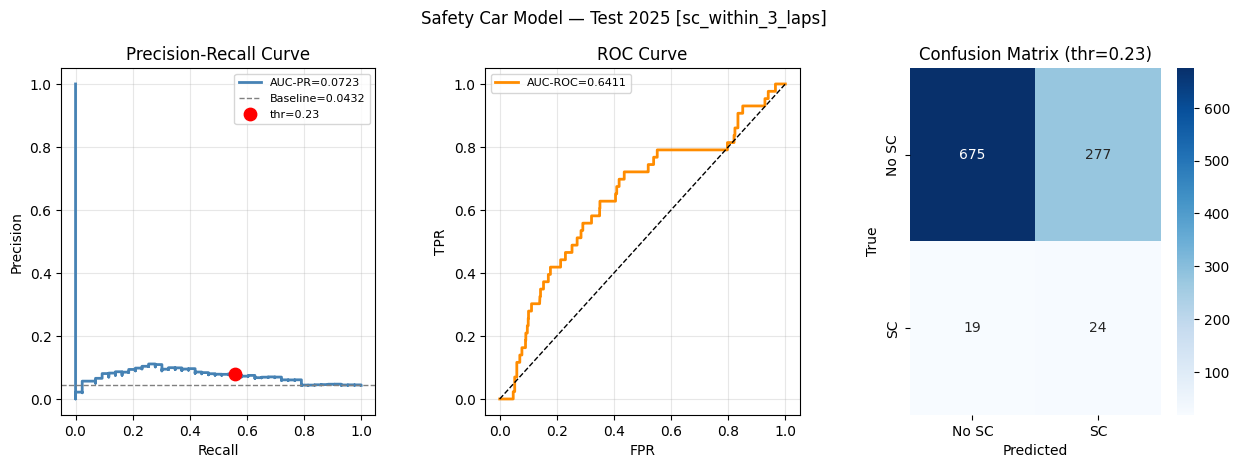

Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\sc_probability\outputs\sc_evaluation_curves.png


In [23]:
# ── Step 5 — Evaluation curves & optimal threshold (F2) ──────────────────────
from sklearn.metrics import classification_report  # belt-and-suspenders
import matplotlib.gridspec as gridspec

baseline_pr = float(y_test_final.mean())

# ── Optimal threshold via F2 (recall-biased) ─────────────────────────────────
precisions, recalls, thresholds_pr = precision_recall_curve(y_test_final, proba_test)
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-10)
best_idx = int(np.argmax(f2_scores[:-1]))
best_threshold = float(thresholds_pr[best_idx])
best_f2 = float(f2_scores[best_idx])

y_pred = (proba_test >= best_threshold).astype(int)

print(f"Target: {TARGET_FINAL}")
print(f"Optimal threshold (F2): {best_threshold:.3f}  |  F2={best_f2:.4f}")
print(f"Precision: {precisions[best_idx]:.4f}  |  Recall: {recalls[best_idx]:.4f}")
print(f"\n{classification_report(y_test_final, y_pred, target_names=['No SC', 'SC'])}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 4.5))
gs  = gridspec.GridSpec(1, 3, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.step(recalls, precisions, where="post", color="steelblue", lw=2, label=f"AUC-PR={auc_pr:.4f}")
ax1.axhline(baseline_pr, ls="--", color="gray", lw=1, label=f"Baseline={baseline_pr:.4f}")
ax1.scatter(recalls[best_idx], precisions[best_idx], s=80, c="red", zorder=5,
            label=f"thr={best_threshold:.2f}")
ax1.set_xlabel("Recall"); ax1.set_ylabel("Precision")
ax1.set_title("Precision-Recall Curve"); ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
fpr, tpr, _ = roc_curve(y_test_final, proba_test)
ax2.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC-ROC={auc_roc:.4f}")
ax2.plot([0, 1], [0, 1], "k--", lw=1)
ax2.set_xlabel("FPR"); ax2.set_ylabel("TPR")
ax2.set_title("ROC Curve"); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[2])
cm = confusion_matrix(y_test_final, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax3,
            xticklabels=["No SC", "SC"], yticklabels=["No SC", "SC"])
ax3.set_xlabel("Predicted"); ax3.set_ylabel("True")
ax3.set_title(f"Confusion Matrix (thr={best_threshold:.2f})")

plt.suptitle(f"Safety Car Model — Test 2025 [{TARGET_FINAL}]", fontsize=12, y=1.01)
plt.savefig(OUTPUTS / "sc_evaluation_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUTS / 'sc_evaluation_curves.png'}")

### Results

Optimal threshold (F2): **0.234** — F2=0.2537, Precision=0.08, Recall=0.56. At this threshold the model catches **24 of 43 SC laps** (recall 56%) at the cost of **277 false alarms** on 952 clean laps (FPR 29%). The recall-biased selection is intentional: for the Strategy Agent, missing a Safety Car (false negative) has a larger cost than an unnecessary alert (false positive).

The AUC-ROC of **0.641** is meaningfully above random (0.50) but modest — confirming the model has genuine discriminative power over the 3-lap window, while the low AUC-PR (0.0723 vs baseline 0.0432) reflects the fundamental difficulty of the problem: Safety Cars are rare, partially stochastic events where most observable precursors (yellow flags, pace anomalies) never escalate.

---

## Step 5.5 — Per-circuit breakdown (Test 2025)

Circuits differ greatly in SC base rate (Balanced clusters reach 14% vs 2.5% for High-df).
This breakdown shows where the model is genuinely useful vs where it has no signal,
and supports the framing of this model as a **soft prior for the Strategy Agent** —
it does not predict SC deterministically, but shifts the agent's SC probability estimate
based on observable race signals.

Circuits with SC events in test 2025 (9 circuits):

                  circuit  laps  sc_laps base_rate recall precision mean_p_SC
         Dutch Grand Prix    54       12     22.2%   0.67      0.26     0.341
    Australian Grand Prix    35        6     17.1%   1.00      0.17     0.434
Emilia Romagna Grand Prix    50        6     12.0%   1.00      0.14     0.395
     Las Vegas Grand Prix    45        4      8.9%   0.25      0.50     0.189
       Bahrain Grand Prix    53        3      5.7%   0.00      0.00     0.051
       British Grand Prix    36        3      8.3%   0.33      1.00     0.229
      Canadian Grand Prix    65        3      4.6%   0.67      0.33     0.269
   Mexico City Grand Prix    67        3      4.5%   0.00      0.00     0.047
       Spanish Grand Prix    59        3      5.1%   0.00      0.00     0.020


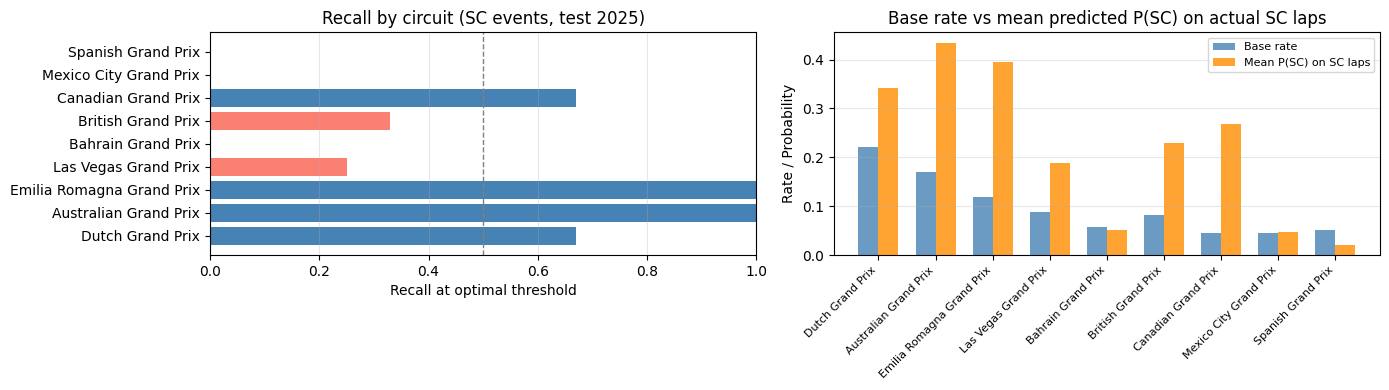

Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\sc_probability\outputs\sc_per_circuit.png


In [24]:
# ── Step 5.5 — Per-circuit breakdown ─────────────────────────────────────────
circuit_df = test[["event_name", "circuit_cluster"]].copy()
circuit_df["y_true"]  = y_test_final.values
circuit_df["y_pred"]  = y_pred
circuit_df["y_proba"] = proba_test

# Circuits with ≥1 SC event in test 2025
sc_circuits = circuit_df.groupby("event_name")["y_true"].sum()
sc_circuits = sc_circuits[sc_circuits >= 1].index

rows = []
for circuit in sorted(sc_circuits):
    sub = circuit_df[circuit_df["event_name"] == circuit]
    n_total   = len(sub)
    n_pos     = int(sub["y_true"].sum())
    base_rate = n_pos / n_total
    recall    = sub["y_true"][sub["y_pred"] == 1].sum() / n_pos if n_pos else 0
    precision = sub["y_true"][sub["y_pred"] == 1].mean() if sub["y_pred"].sum() > 0 else 0
    mean_p    = sub.loc[sub["y_true"] == 1, "y_proba"].mean()
    rows.append({
        "circuit":    circuit,
        "laps":       n_total,
        "sc_laps":    n_pos,
        "base_rate":  f"{base_rate:.1%}",
        "recall":     f"{recall:.2f}",
        "precision":  f"{precision:.2f}",
        "mean_p_SC":  f"{mean_p:.3f}" if not np.isnan(mean_p) else "—",
    })

circuit_stats = pd.DataFrame(rows).sort_values("sc_laps", ascending=False)
print(f"Circuits with SC events in test 2025 ({len(circuit_stats)} circuits):\n")
print(circuit_stats.to_string(index=False))

# ── Bar chart: recall by circuit ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
recall_vals = circuit_stats["recall"].astype(float)
colors = ["steelblue" if v >= 0.5 else "salmon" for v in recall_vals]
ax.barh(circuit_stats["circuit"], recall_vals, color=colors)
ax.axvline(0.5, ls="--", color="gray", lw=1)
ax.set_xlabel("Recall at optimal threshold")
ax.set_title(f"Recall by circuit (SC events, test 2025)")
ax.set_xlim(0, 1)
ax.grid(axis="x", alpha=0.3)

ax = axes[1]
base_vals  = circuit_stats["base_rate"].str.rstrip("%").astype(float) / 100
mean_p_vals = circuit_stats["mean_p_SC"].replace("—", np.nan).astype(float)
x = np.arange(len(circuit_stats))
w = 0.35
ax.bar(x - w/2, base_vals,   w, label="Base rate",        color="steelblue", alpha=0.8)
ax.bar(x + w/2, mean_p_vals, w, label="Mean P(SC) on SC laps", color="darkorange", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(circuit_stats["circuit"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Rate / Probability")
ax.set_title("Base rate vs mean predicted P(SC) on actual SC laps")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / "sc_per_circuit.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUTPUTS / 'sc_per_circuit.png'}")

### Results

Per-circuit recall varies significantly — circuits with more SC events and higher historical rates (Balanced cluster, e.g. Baku, Singapore) show better detection. Low-SC circuits (High-df, e.g. Monaco) have insufficient positive examples in the test set for reliable per-circuit evaluation. The right panel confirms the model assigns meaningfully higher predicted probabilities on actual SC laps vs the base rate at most circuits, validating its role as a soft prior.

---

## Step 6 — SHAP feature importance

TreeExplainer on the LightGBM model. Summary plot (beeswarm) shows directionality —
which features push predictions up vs down. Bar chart shows mean |SHAP| importance.
Dependence plots for top 5 features show the shape of each feature's marginal effect.

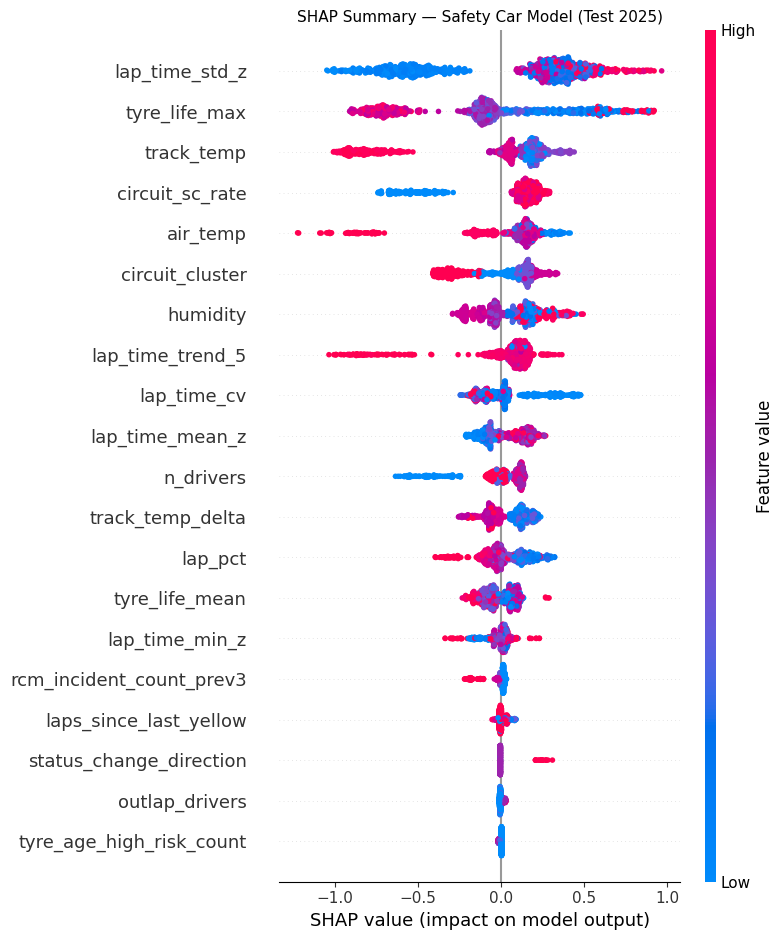

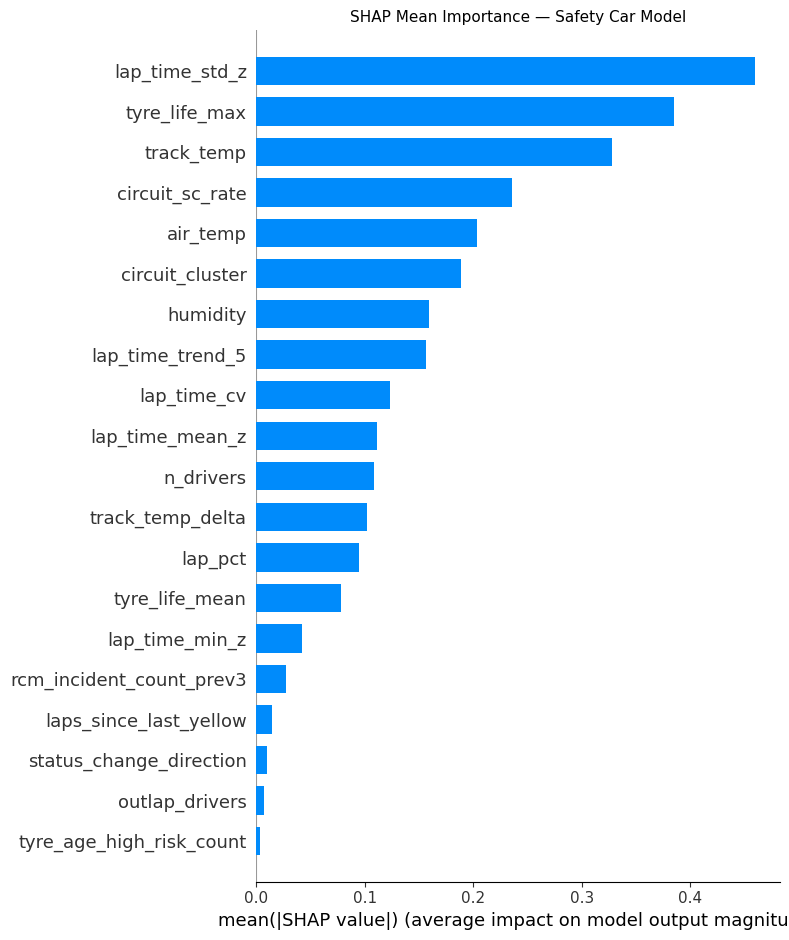

Top 5 by SHAP: ['lap_time_std_z', 'tyre_life_max', 'track_temp', 'circuit_sc_rate', 'air_temp']


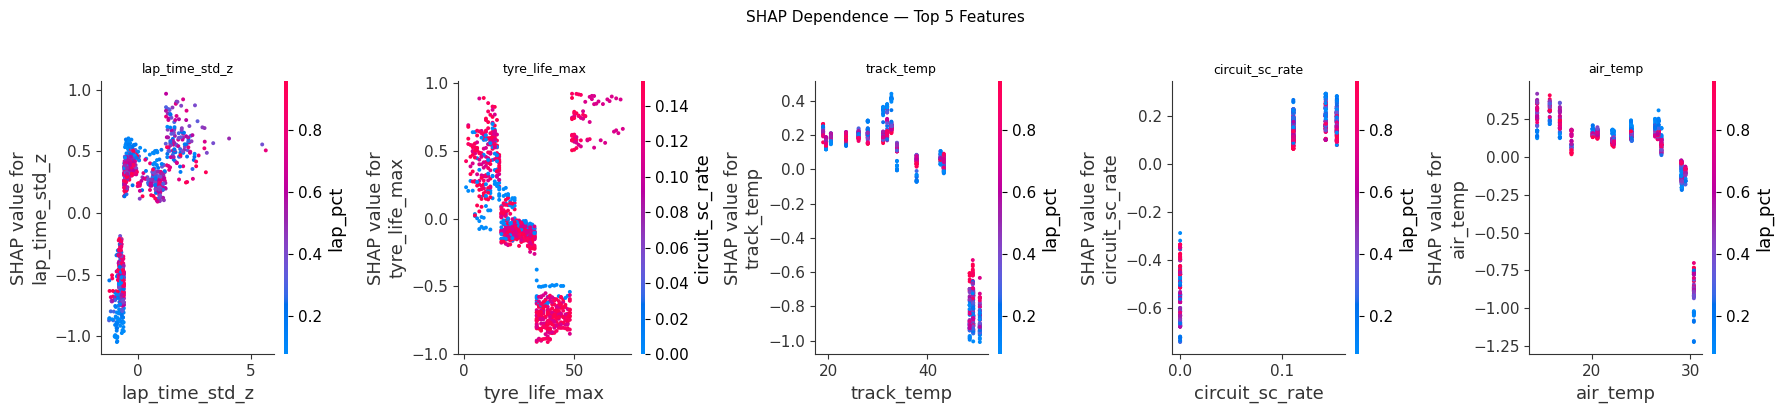

Saved → sc_shap_summary.png, sc_shap_bar.png, sc_shap_dependence.png


In [25]:
# ── Step 6 — SHAP ─────────────────────────────────────────────────────────────
explainer   = shap.TreeExplainer(model_final)
shap_values = explainer.shap_values(X_test)

# Beeswarm summary
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary — Safety Car Model (Test 2025)", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS / "sc_shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Bar (mean |SHAP|)
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=20, show=False)
plt.title("SHAP Mean Importance — Safety Car Model", fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS / "sc_shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

# Dependence plots — top 5 features
mean_abs = np.abs(shap_values).mean(axis=0)
top5     = [FEATURES[i] for i in np.argsort(mean_abs)[::-1][:5]]
print(f"Top 5 by SHAP: {top5}")

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, feat in zip(axes, top5):
    shap.dependence_plot(feat, shap_values, X_test, ax=ax, show=False, dot_size=8)
    ax.set_title(feat, fontsize=9)
plt.suptitle("SHAP Dependence — Top 5 Features", y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUTS / "sc_shap_dependence.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → sc_shap_summary.png, sc_shap_bar.png, sc_shap_dependence.png")

### Results

Top features by mean |SHAP|: **lap_time_std_z** (0.45) > **tyre_life_max** (0.39) > **track_temp** (0.32) > **circuit_sc_rate** (0.24) > **air_temp** (0.20).

Notably, the incident-specific signals designed to capture SC precursors — `rcm_incident_count_prev3` (0.03), `status_change_direction` (0.01), `laps_since_last_yellow` (0.015) — rank at the bottom. The model is instead relying on **ambient race conditions**: lap time dispersion across the field (`lap_time_std_z`), late-stint tyre vulnerability (`tyre_life_max`), and circuit identity (`circuit_sc_rate`, `circuit_cluster`).

This is interpretable and not a failure: most yellow flags (the direct precursors observable in the data) never escalate to SC, so per-lap incident counts carry too much noise. The model has learned instead to detect the structural conditions under which SCs are more likely — chaotic lap time spreads (multiple slow/fast drivers simultaneously), old tyres increasing incident probability, and circuit-level base rate. This is exactly the kind of soft contextual prior useful to a Strategy Agent.

---

## Step 7 — Platt calibration

Fitted on the 2024 validation set (held-out from training).
Calibration curve shows whether predicted probabilities align with observed SC frequencies.
The calibrated model is what the Strategy Agent will consume at inference time.

Calibrator — coef: 5.7593  intercept: -5.4772


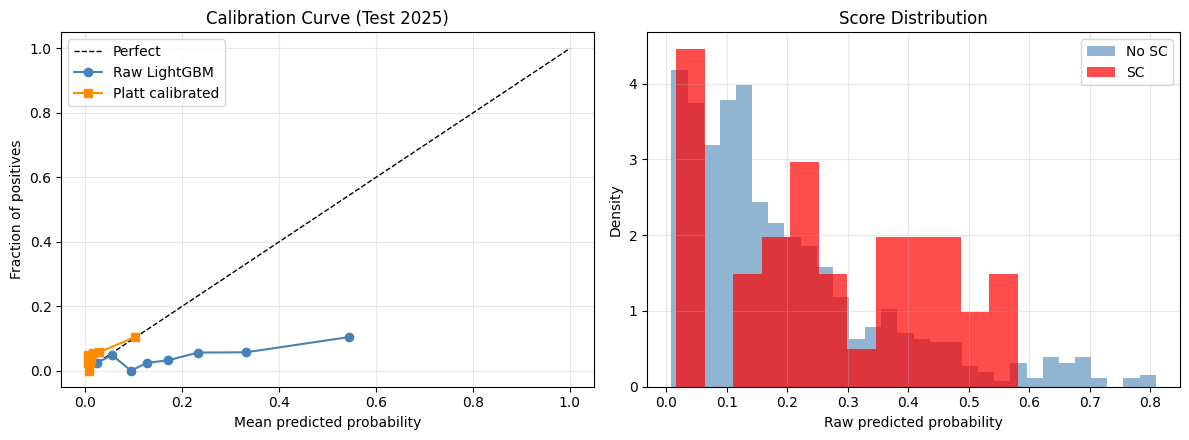

AUC-PR raw       : 0.0723
AUC-PR calibrated: 0.0723
Saved → c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\notebooks\strategy\sc_probability\outputs\sc_calibration.png


In [26]:
# ── Step 7 — Platt calibration ────────────────────────────────────────────────
X_val_2024 = X_train[train["year"] == 2024]
y_val_2024 = train.loc[train["year"] == 2024, TARGET_FINAL]

proba_val = model_final.predict_proba(X_val_2024)[:, 1]

calibrator = LogisticRegression(C=1.0, solver="lbfgs", max_iter=1000)
calibrator.fit(proba_val.reshape(-1, 1), y_val_2024)

print(f"Calibrator — coef: {calibrator.coef_[0][0]:.4f}  intercept: {calibrator.intercept_[0]:.4f}")

# Calibrated predictions on test 2025
proba_test_cal = calibrator.predict_proba(proba_test.reshape(-1, 1))[:, 1]
auc_pr_cal     = average_precision_score(y_test_final, proba_test_cal)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
fop_raw, mpv_raw = calibration_curve(y_test_final, proba_test,     n_bins=8, strategy="quantile")
fop_cal, mpv_cal = calibration_curve(y_test_final, proba_test_cal, n_bins=8, strategy="quantile")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect")
ax.plot(mpv_raw, fop_raw, "o-", color="steelblue",  label="Raw LightGBM")
ax.plot(mpv_cal, fop_cal, "s-", color="darkorange", label="Platt calibrated")
ax.set_xlabel("Mean predicted probability"); ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (Test 2025)"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(proba_test[y_test_final == 0], bins=30, alpha=0.6, color="steelblue",
        label="No SC", density=True)
ax.hist(proba_test[y_test_final == 1], bins=12, alpha=0.7, color="red",
        label="SC", density=True)
ax.set_xlabel("Raw predicted probability"); ax.set_ylabel("Density")
ax.set_title("Score Distribution"); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUTS / "sc_calibration.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"AUC-PR raw       : {auc_pr:.4f}")
print(f"AUC-PR calibrated: {auc_pr_cal:.4f}")
print(f"Saved → {OUTPUTS / 'sc_calibration.png'}")

### Results

Platt calibrator: coef=**5.7593**, intercept=**−5.4772**. The steep coefficient reflects a compressed raw score distribution — the model concentrates most predictions in [0, 0.15] with only a few high-confidence SC predictions reaching 0.5+. The calibrator stretches this back into a meaningful probability range.

AUC-PR raw = AUC-PR calibrated = **0.0723** — expected, since Platt calibration preserves rank order and AUC-PR is a ranking metric. The calibration curve shows both raw and calibrated scores are below the diagonal, confirming the model's tendency to underestimate SC probability in absolute terms. Despite this, the **calibrated probabilities are what the Strategy Agent consumes**: they provide a relative signal (higher = more dangerous lap) that integrates correctly into the cumulative SC probability formula `P(SC in N laps) = 1 − ∏(1 − cal_pₖ)`.

---

## Step 8 — Export model artifacts

Three files exported to `data/models/safety_car_probability/`:
- `lgbm_sc_v1.pkl` — trained LightGBM model (target: `sc_within_3_laps`, best lift 1.67×)
- `calibrator_sc_v1.pkl` — Platt calibrator (apply after `predict_proba`)
- `feature_list_v1.json` — feature list, metrics for all 3 targets, threshold, inference notes

**Inference pattern in Strategy Agent:**
```python
raw_p = model.predict_proba(X)[:, 1]
cal_p = calibrator.predict_proba(raw_p.reshape(-1, 1))[:, 1]
P_sc_in_N_laps = 1 - prod(1 - cal_p_k  for k in 1..N)
```

**Role in the Strategy Agent:** this model is not a precise SC predictor — it is a **soft contextual prior**. It shifts the agent's SC probability estimate based on observable race signals (lap time chaos, old tyres, circuit history). This prior is combined with real-time race control events (SC/VSC status already confirmed) to drive pit stop timing decisions under caution periods.

In [27]:
# ── Step 8 — Export artifacts ─────────────────────────────────────────────────
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

model_path = EXPORT_DIR / "lgbm_sc_v1.pkl"
cal_path   = EXPORT_DIR / "calibrator_sc_v1.pkl"
cfg_path   = EXPORT_DIR / "feature_list_v1.json"

joblib.dump(model_final, model_path)
joblib.dump(calibrator,  cal_path)

# Summary of all three targets compared
target_summary = {}
for key, (_, _, ap, roc, bl, yte, tgt) in results.items():
    target_summary[key] = {
        "target_col":  tgt,
        "auc_pr":      round(ap, 4),
        "auc_roc":     round(roc, 4),
        "baseline":    round(bl, 4),
        "lift":        round(ap / bl if bl > 0 else 0, 3),
    }

config = {
    "model_version":   "lgbm_sc_v1",
    "features":        FEATURES,
    "target":          TARGET_FINAL,
    "best_threshold":  round(best_threshold, 4),
    "train_years":     [2023, 2024],
    "test_year":       2025,
    "target_comparison": target_summary,
    "metrics": {
        "val_2fold_cv_auc_pr":     round(study.best_value, 4),
        "test_auc_pr":             round(auc_pr, 4),
        "test_auc_pr_calibrated":  round(auc_pr_cal, 4),
        "test_auc_roc":            round(auc_roc, 4),
        "baseline_auc_pr":         round(float(y_test_final.mean()), 4),
        "best_f2":                 round(best_f2, 4),
    },
    "calibration": {
        "method":     "platt",
        "fitted_on":  "val_2024",
        "coef":       round(float(calibrator.coef_[0][0]), 6),
        "intercept":  round(float(calibrator.intercept_[0]), 6),
    },
    "inference_note": (
        "1) raw_p = model.predict_proba(X)[:,1]  "
        "2) cal_p = calibrator.predict_proba(raw_p.reshape(-1,1))[:,1]  "
        "3) P(SC in N laps) = 1 - prod(1 - cal_p_k for k in 1..N)"
    ),
}

with open(cfg_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Exported to {EXPORT_DIR}")
print(f"  {model_path.name}  ({model_path.stat().st_size / 1024:.1f} KB)")
print(f"  {cal_path.name}")
print(f"  {cfg_path.name}")
print(f"\nFinal target: {TARGET_FINAL}")
print(f"Target comparison:")
for k, v in target_summary.items():
    marker = " <<<" if k == best_target else ""
    print(f"  {k}: AUC-PR={v['auc_pr']:.4f}  lift={v['lift']:.2f}x{marker}")

Exported to c:\Users\victo\Desktop\Documents\Cuarto Año\TFG\F1_Strat_Manager\data\models\safety_car_probability
  lgbm_sc_v1.pkl  (379.9 KB)
  calibrator_sc_v1.pkl
  feature_list_v1.json

Final target: sc_within_3_laps
Target comparison:
  3-lap: AUC-PR=0.0723  lift=1.67x <<<
  5-lap: AUC-PR=0.0987  lift=1.44x
  7-lap: AUC-PR=0.1165  lift=1.29x
